In [3]:
# --- Imports & plotting defaults ---
import json
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

plt.rcParams["figure.dpi"] = 150
sns.set(context="talk", style="whitegrid")

def savefig(path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()

def savetables(df, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

JSON_DIR = "/net/projects2/vanguard/MAMA-MIA-syn60868042/patient_info_files"
OUT_DIR  = "eda_out"

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
Path(f"{OUT_DIR}/figs").mkdir(parents=True, exist_ok=True)
Path(f"{OUT_DIR}/tables").mkdir(parents=True, exist_ok=True)

### Parsing

In [5]:
def get_patient_id(path: Path, js: Dict[str, Any]) -> str:
    return js.get("patient_id", path.stem)

def get_age(js) -> Optional[float]:
    '''
    Gets age, returns None if missing
    '''
    age = js.get("clinical_data", {}).get("age", None)
    try:
        return float(age) if age not in (None, "") else None
    except Exception:
        return None

def get_subtype(js: Dict[str, Any]) -> str:
    '''
    Gets tumor subtype, returns unknown if missing
    '''
    subtype = js.get("primary_lesion", {}).get("tumor_subtype", "")
    s = str(subtype).strip().lower()
    return s if s else "unknown"   # In the README: missing subtype = "unknown"

def get_label_optional(js: Dict[str, Any]) -> Optional[int]:
    """
    Extracts the pathologic complete response (pCR) label from the JSON file.

    Returns:
        int (0 or 1): if a valid pCR label exists.
        None: if the label is missing, blank, or malformed.

    This function is "optional"; it allows unlabeled patients to remain
    in the dataset so they can still receive predictions (y_pred_score), even though
    they are excluded from model training and AUC computation.
    """
    # Try to get pCR field
    lab = js.get("primary_lesion", {}).get("pcr", None)

    # If missing or blank, return None
    if lab in (None, ""):
        return None

    try:
        # Convert "0" or "1" (string or int) into integer form
        return int(lab)
    except Exception:
        # If conversion fails (e.g. "NA" or malformed), treat as unlabeled
        return None


def get_bbox_volume(js: Dict[str, Any]) -> Optional[float]:
    bc = js.get("primary_lesion", {}).get("breast_coordinates", {})
    try:
        x_min = float(bc.get("x_min"))
        x_max = float(bc.get("x_max"))
        y_min = float(bc.get("y_min"))
        y_max = float(bc.get("y_max"))
        z_min = float(bc.get("z_min"))
        z_max = float(bc.get("z_max"))
        dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min
        vol = dx * dy * dz
        return vol if (dx > 0 and dy > 0 and dz > 0) else None
    except Exception:
        return None

In [6]:
def get_patient_id(path: Path, js: Dict[str, Any]) -> str:
    return js.get("patient_id", path.stem)

def get_site(js: Dict[str, Any]) -> str:
    site = js.get("imaging_data", {}).get("site", "")
    return str(site).strip().upper() if site else "UNKNOWN"

def get_dataset(js: Dict[str, Any]) -> str:
    ds = js.get("imaging_data", {}).get("dataset", None)
    return str(ds).strip().upper() if ds else "UNKNOWN"

def get_age(js) -> Optional[float]:
    '''
    Gets age, returns None if missing
    '''
    age = js.get("clinical_data", {}).get("age", None)
    try:
        return float(age) if age not in (None, "") else None
    except Exception:
        return None

def get_subtype(js: Dict[str, Any]) -> str:
    '''
    Gets tumor subtype, returns unknown if missing
    '''
    subtype = js.get("primary_lesion", {}).get("tumor_subtype", "")
    s = str(subtype).strip().lower()
    return s if s else "unknown"   # In the README: missing subtype = "unknown"

def get_label_optional(js: Dict[str, Any]) -> Optional[int]:
    """
    Extracts the pathologic complete response (pCR) label from the JSON file.

    Returns:
        int (0 or 1): if a valid pCR label exists.
        None: if the label is missing, blank, or malformed.

    This function is "optional"; it allows unlabeled patients to remain
    in the dataset so they can still receive predictions (y_pred_score), even though
    they are excluded from model training and AUC computation.
    """
    # Try to get pCR field
    lab = js.get("primary_lesion", {}).get("pcr", None)

    # If missing or blank, return None
    if lab in (None, ""):
        return None

    try:
        # Convert "0" or "1" (string or int) into integer form
        return int(lab)
    except Exception:
        # If conversion fails (e.g. "NA" or malformed), treat as unlabeled
        return None
    
def get_menopausal(js: Dict[str, Any]) -> str:
    raw = js.get("clinical_data", {}).get("menopausal_status", "")
    s = str(raw).strip().lower()
    if s.startswith("pre"):   return "pre" #some have extra comments after, so just look for pre/post/peri
    if s.startswith("post"):  return "post"
    if s.startswith("peri"):  return "peri"
    if s in ("", "na", "unknown"): return "unknown"
    if "pre" in s:  return "pre"
    if "post" in s: return "post"
    if "peri" in s: return "peri"
    return "unknown"

def get_breast_density(js: Dict[str, Any]) -> str: #if there, a lot of the breast density fields are empty
    density = js.get("clinical_data", {}).get("breast_density", "")
    s = str(density).strip().lower()
    return s if s else "unknown"

def get_laterality(js: Dict[str, Any]) -> str:
    bil = js.get("imaging_data", {}).get("bilateral", None)
    if bil is True:
        return "bilateral"
    if bil is False:
        return "unilateral"
    return "unknown"

def get_bbox_volume(js: Dict[str, Any]) -> Optional[float]:
    bc = js.get("primary_lesion", {}).get("breast_coordinates", {})
    try:
        x_min = float(bc.get("x_min"))
        x_max = float(bc.get("x_max"))
        y_min = float(bc.get("y_min"))
        y_max = float(bc.get("y_max"))
        z_min = float(bc.get("z_min"))
        z_max = float(bc.get("z_max"))
        dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min
        vol = dx * dy * dz
        return vol if (dx > 0 and dy > 0 and dz > 0) else None
    except Exception:
        return None
    
def get_field_strength(js: Dict[str, Any]) -> Optional[float]:
    val = js.get("imaging_data", {}).get("field_strength", None)
    return float(val) if val is not None else None

def get_manufacturer(js: Dict[str, Any]) -> str:
    val = js.get("imaging_data", {}).get("scanner_manufacturer", "")
    return str(val).strip() if val else "unknown"

def get_model(js: Dict[str, Any]) -> str:
    val = js.get("imaging_data", {}).get("scanner_model", "")
    return str(val).strip() if val else "unknown"

def get_echo_time(js: Dict[str, Any]) -> Optional[float]:
    val = js.get("imaging_data", {}).get("echo_time", None)
    return float(val) if val is not None else None

def get_repetition_time(js: Dict[str, Any]) -> Optional[float]:
    val = js.get("imaging_data", {}).get("repetition_time", None)
    return float(val) if val is not None else None

### Loading Data

In [7]:
def load_data(json_dir: str) -> pd.DataFrame:
    rows = []
    p = Path(json_dir)
    files = sorted(p.glob("*.json"))

    for f in files:
        try:
            with open(f, "r") as fh:
                js = json.load(fh)
        except Exception as e:
            print(f"[ERR] Failed to parse {f}: {e}")
            continue

        row = {
            "patient_id":         get_patient_id(f, js),
            "dataset":            get_dataset(js),
            "site":               get_site(js),
            "age":                get_age(js),
            "subtype":            get_subtype(js),
            "pcr":                get_label_optional(js),
            "menopausal":         get_menopausal(js),
            "breast_density":     get_breast_density(js),
            "laterality":         get_laterality(js),
            "bbox_volume":        get_bbox_volume(js),
            "field_strength":     get_field_strength(js),
            "manufacturer":       get_manufacturer(js),
            "model":              get_model(js),
            "echo_time":          get_echo_time(js),
            "repetition_time":    get_repetition_time(js),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    # pCR label
    df["pcr_label"] = df["pcr"].map({0: "no pCR", 1: "pCR", None: "unlabeled"})

    return df

meta_df = load_data(JSON_DIR)
print(meta_df.shape)
meta_df.head()

(1506, 16)


,patient_id,dataset,site,age,subtype,pcr,menopausal,breast_density,laterality,bbox_volume,field_strength,manufacturer,model,echo_time,repetition_time,pcr_label
0,DUKE_001,DUKE,DUKE,41.0,her2_pure,0.0,pre,unknown,bilateral,12282738.0,1.5,SIEMENS,Avanto,1.360,4.120,no pCR
1,DUKE_002,DUKE,DUKE,38.0,triple_negative,0.0,pre,unknown,bilateral,14248195.0,3.0,GE,Signa HDxt,2.704,6.918,no pCR
2,DUKE_005,DUKE,DUKE,38.0,her2_enriched,1.0,pre,unknown,bilateral,9936687.0,1.5,SIEMENS,Avanto,1.340,4.270,pCR
3,DUKE_009,DUKE,DUKE,56.0,triple_negative,1.0,post,unknown,bilateral,9145422.0,3.0,GE,Signa HDxt,2.604,6.032,pCR
4,DUKE_010,DUKE,DUKE,67.0,triple_negative,0.0,post,unknown,bilateral,12998128.0,3.0,GE,Signa HDxt,2.436,5.668,no pCR


In [8]:
meta_df.info()
meta_df.describe(include="all")
meta_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       1506 non-null   object 
 1   dataset          1506 non-null   object 
 2   site             1506 non-null   object 
 3   age              1503 non-null   float64
 4   subtype          1506 non-null   object 
 5   pcr              1491 non-null   float64
 6   menopausal       1506 non-null   object 
 7   breast_density   1506 non-null   object 
 8   laterality       1506 non-null   object 
 9   bbox_volume      1506 non-null   float64
 10  field_strength   1506 non-null   float64
 11  manufacturer     1506 non-null   object 
 12  model            1506 non-null   object 
 13  echo_time        1506 non-null   float64
 14  repetition_time  1506 non-null   float64
 15  pcr_label        1506 non-null   object 
dtypes: float64(6), object(10)
memory usage: 188.4+ KB


,patient_id,dataset,site,age,subtype,pcr,menopausal,breast_density,laterality,bbox_volume,field_strength,manufacturer,model,echo_time,repetition_time,pcr_label
0,DUKE_001,DUKE,DUKE,41.0,her2_pure,0.0,pre,unknown,bilateral,12282738.0,1.5,SIEMENS,Avanto,1.360,4.120,no pCR
1,DUKE_002,DUKE,DUKE,38.0,triple_negative,0.0,pre,unknown,bilateral,14248195.0,3.0,GE,Signa HDxt,2.704,6.918,no pCR
2,DUKE_005,DUKE,DUKE,38.0,her2_enriched,1.0,pre,unknown,bilateral,9936687.0,1.5,SIEMENS,Avanto,1.340,4.270,pCR
3,DUKE_009,DUKE,DUKE,56.0,triple_negative,1.0,post,unknown,bilateral,9145422.0,3.0,GE,Signa HDxt,2.604,6.032,pCR
4,DUKE_010,DUKE,DUKE,67.0,triple_negative,0.0,post,unknown,bilateral,12998128.0,3.0,GE,Signa HDxt,2.436,5.668,no pCR


#### Missing Data

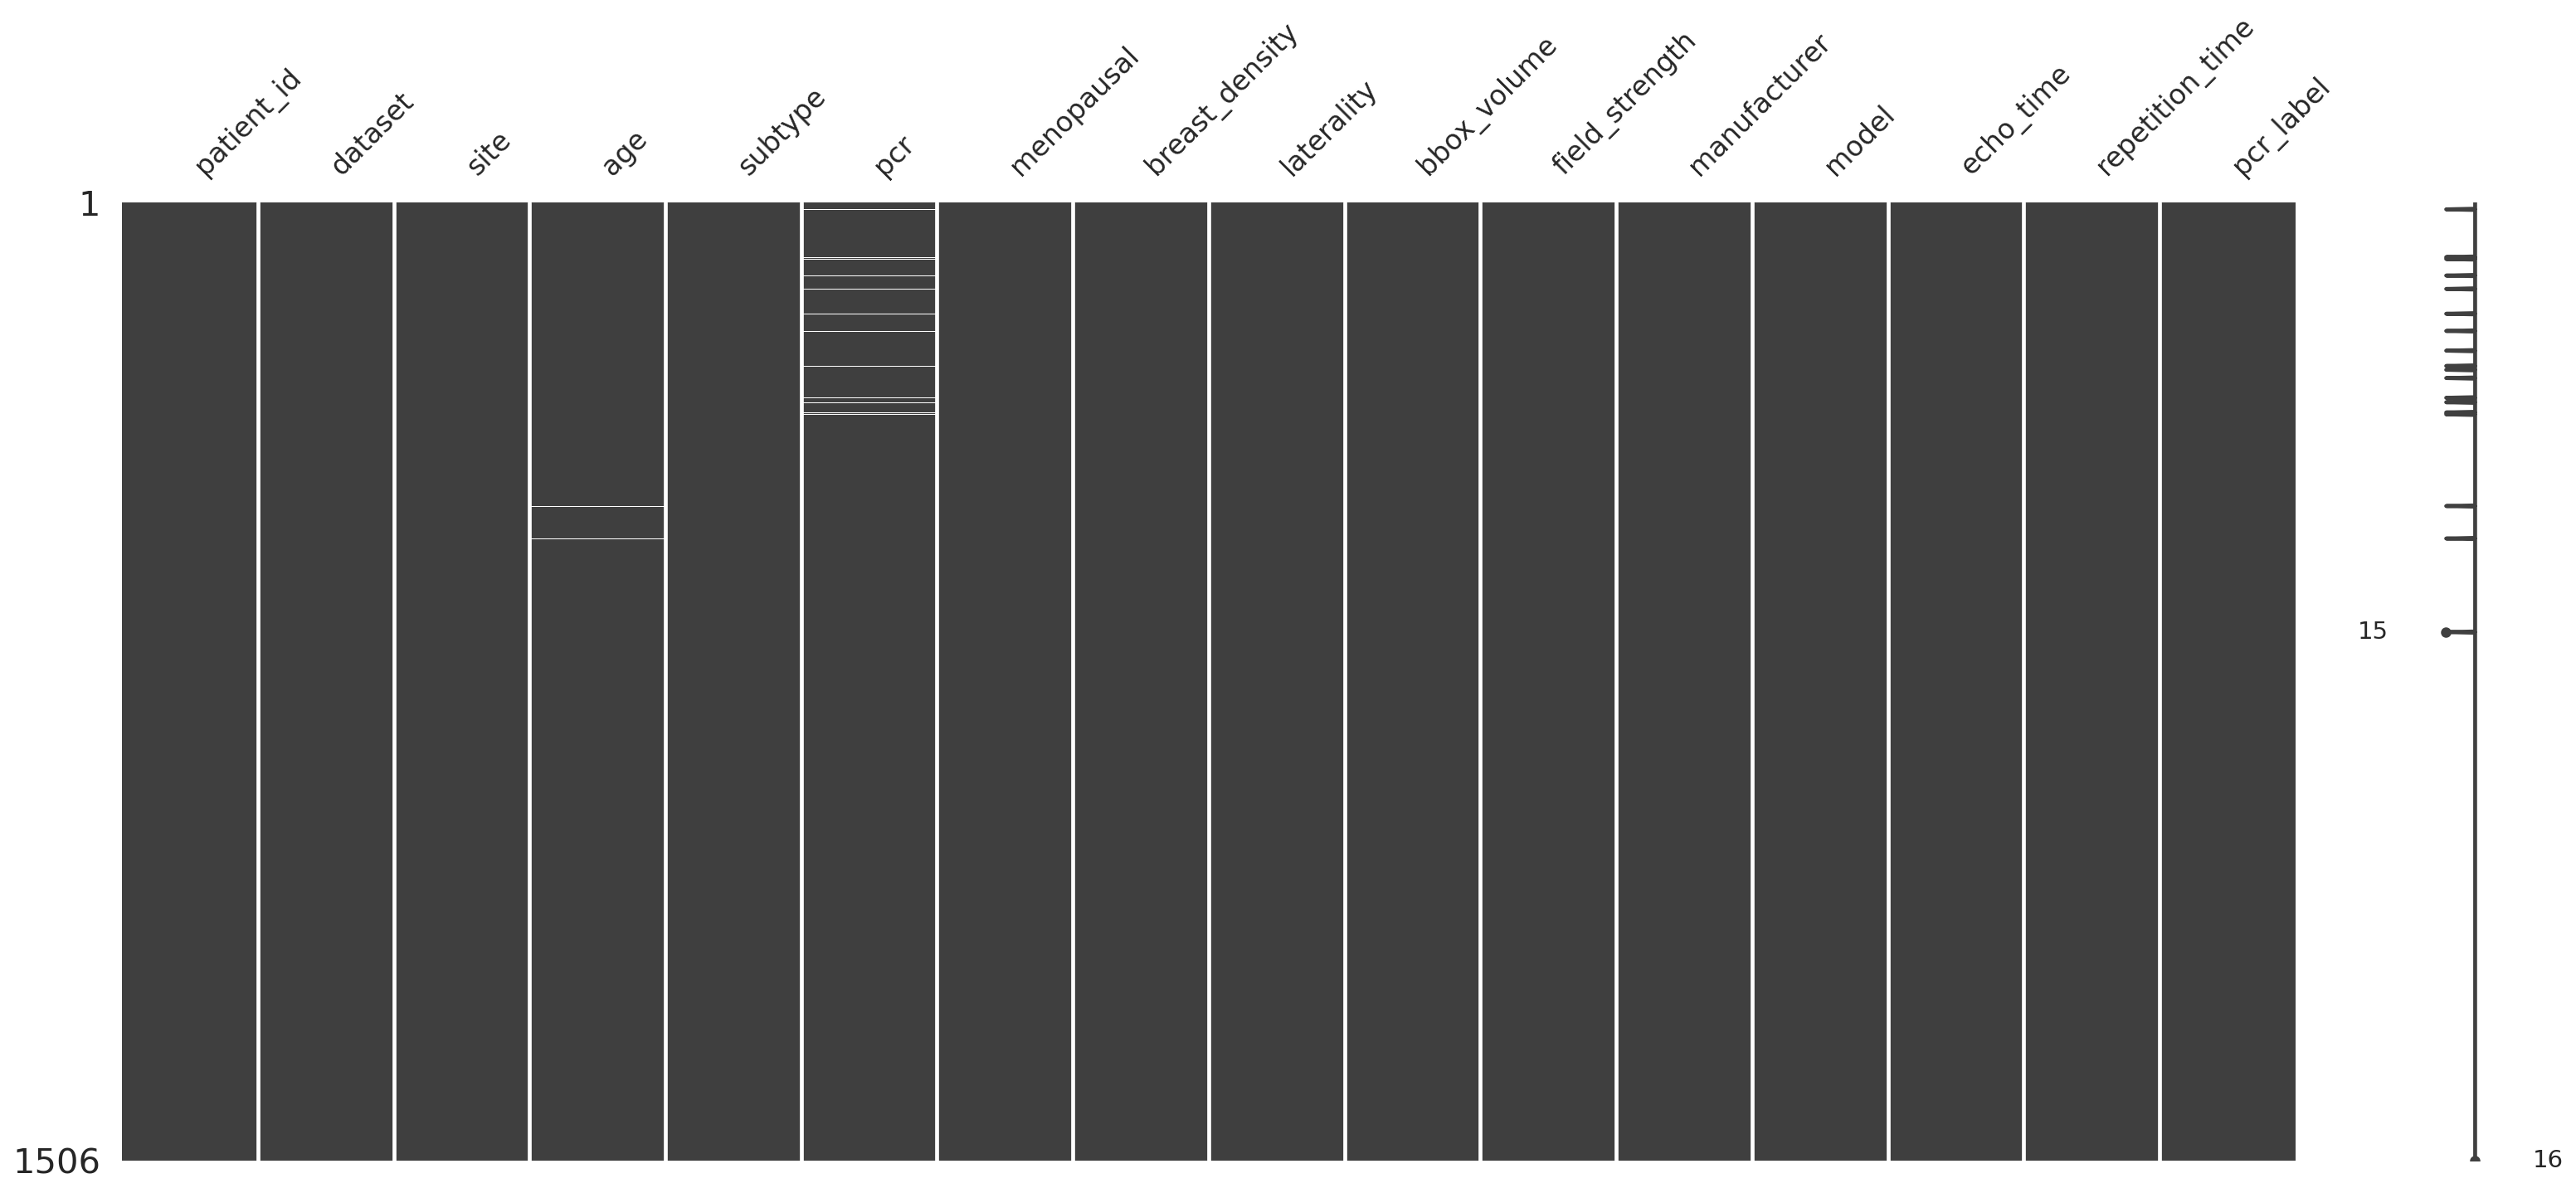

In [9]:
msno.matrix(meta_df)
plt.show()

### Cohort Overview

/tmp/ipykernel_1092878/2781655373.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


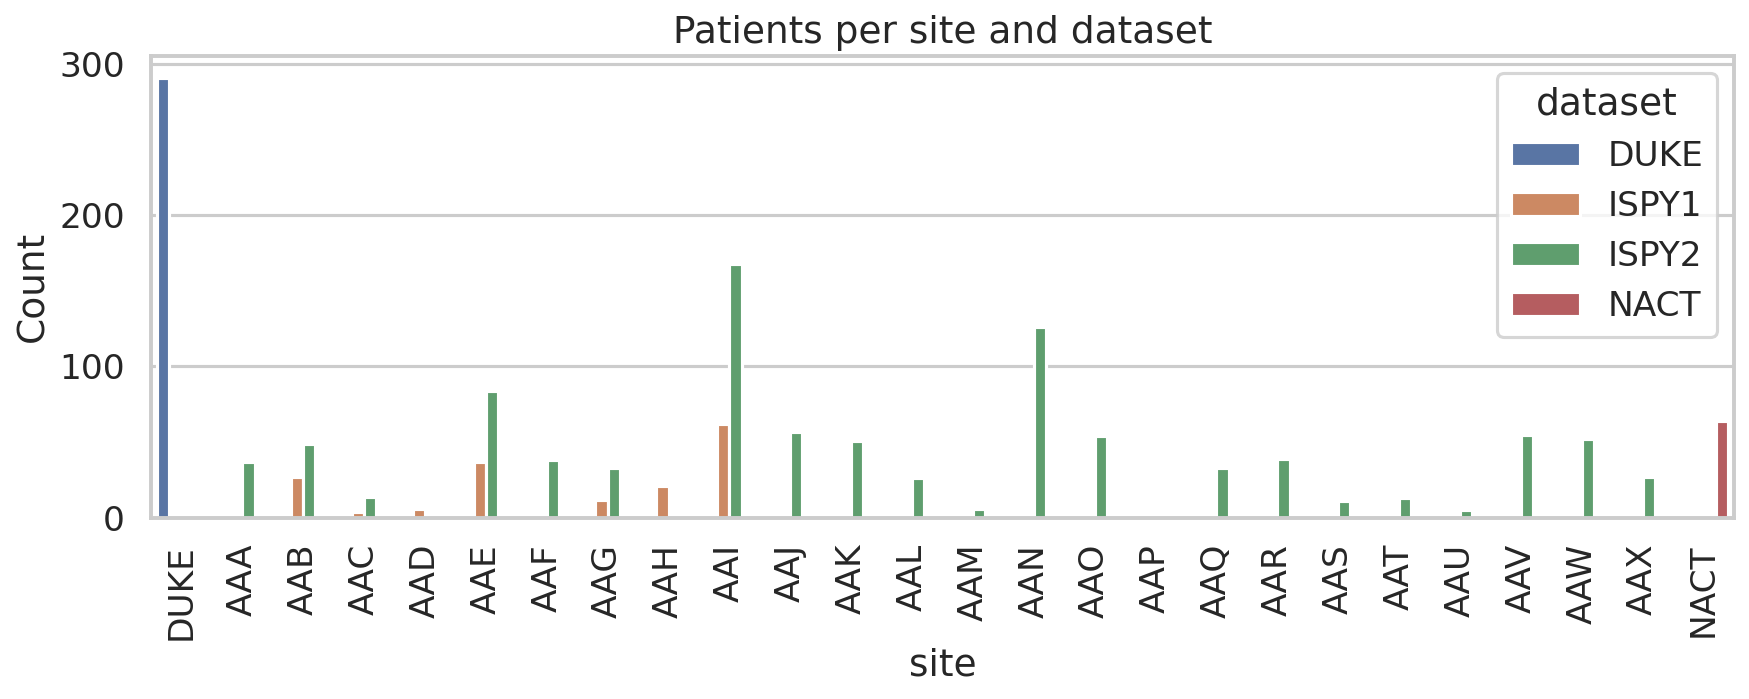

In [10]:
# Patients per dataset and site
site_counts = meta_df.groupby(["dataset", "site"]).size().reset_index(name="n")
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=site_counts, x="site", y="n", hue="dataset", ax=ax)
ax.set_title("Patients per site and dataset")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/patients_per_site.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### Subtype and PCR

In [11]:
pcr_df = meta_df.dropna(subset=["pcr"]).copy()
pcr_df["pcr_cat"] = pcr_df["pcr"].map({0: "no pCR", 1: "pCR"})

# --- Overall pCR rate ---
pcr_rate = pcr_df["pcr"].mean()
print(f"Overall pCR rate: {pcr_rate:.2%} ({pcr_df['pcr'].sum()}/{len(pcr_df)})")

Overall pCR rate: 29.51% (440.0/1491)


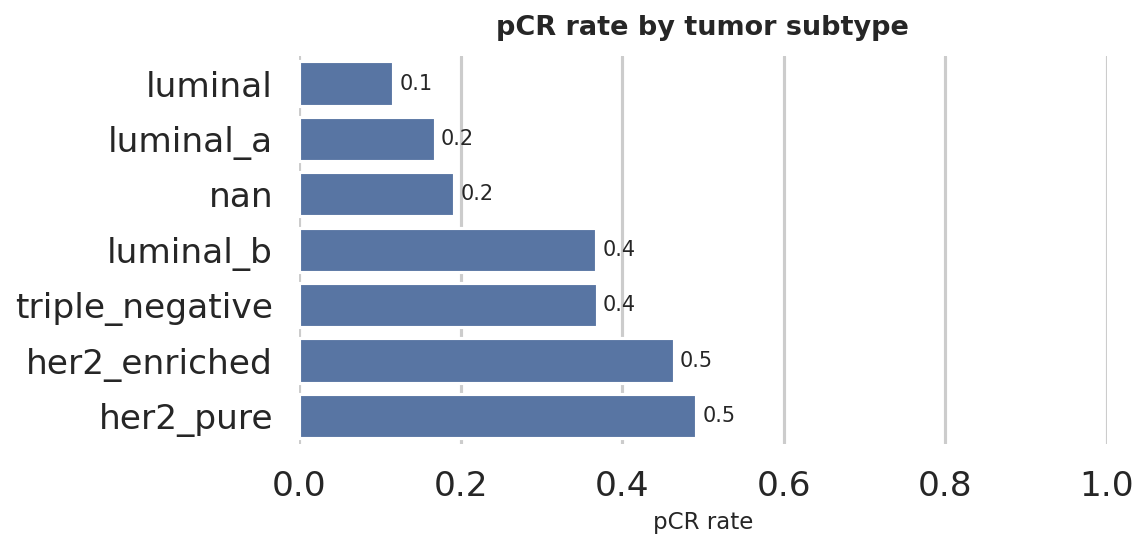

In [20]:
# --- Subtype vs pCR ---
sub_pcr = (
    pcr_df.groupby("subtype")["pcr"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pcr_rate", "count": "n"})
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

sub_pcr_sorted = sub_pcr.sort_values("pcr_rate", ascending=True)

sns.barplot(
    data=sub_pcr_sorted,
    y=sub_pcr_sorted["subtype"],
    x=sub_pcr_sorted["pcr_rate"],
    color="#4B72B0",
    ax=ax
)

ax.set_title("pCR rate by tumor subtype", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("pCR rate", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=10)
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()

fig.savefig(f"{OUT_DIR}/figs/pcr_by_subtype.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

/tmp/ipykernel_1092878/2624756521.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)


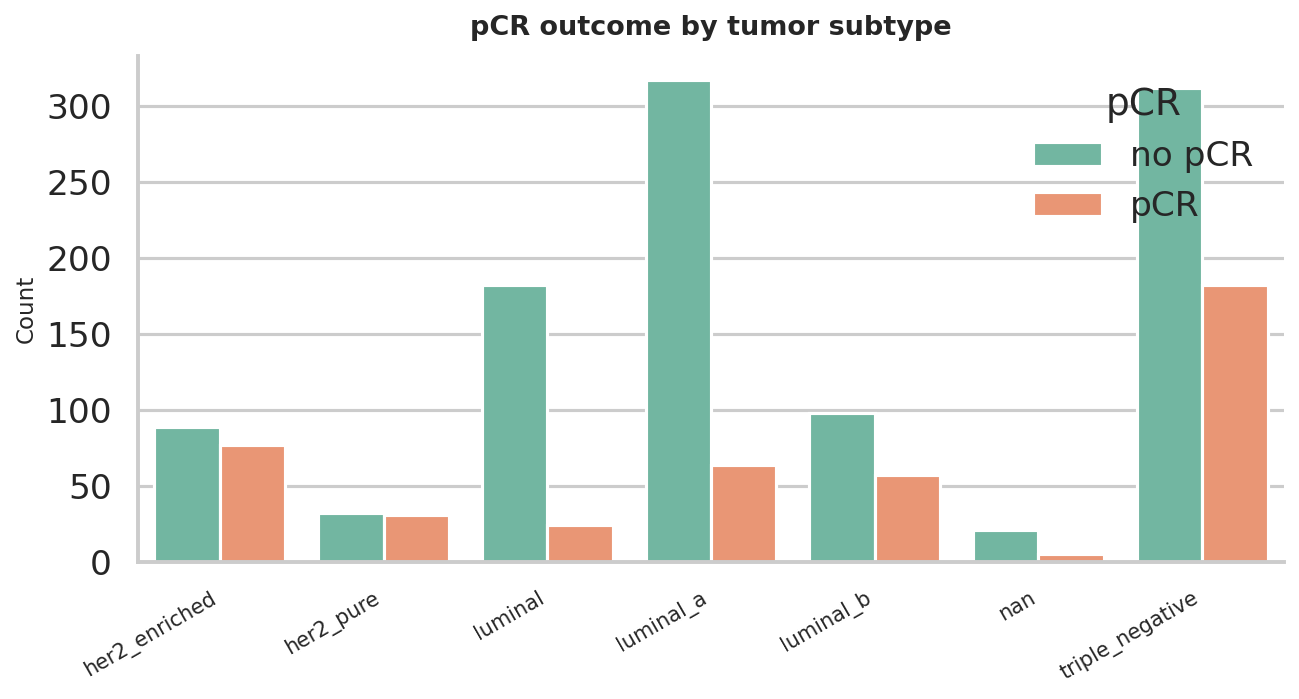

In [22]:
# Stacked Bar
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(
    data=pcr_df,
    x="subtype",
    hue="pcr_cat",
    ax=ax,
    palette="Set2",
    order=sorted(pcr_df["subtype"].dropna().unique())
)

ax.set_title("pCR outcome by tumor subtype", fontsize=13, weight="bold", pad=10)
ax.set_ylabel("Count", fontsize=11)
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.legend(title="pCR", loc="upper right", frameon=False)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/pcr_by_subtype_stacked.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Age Distribution

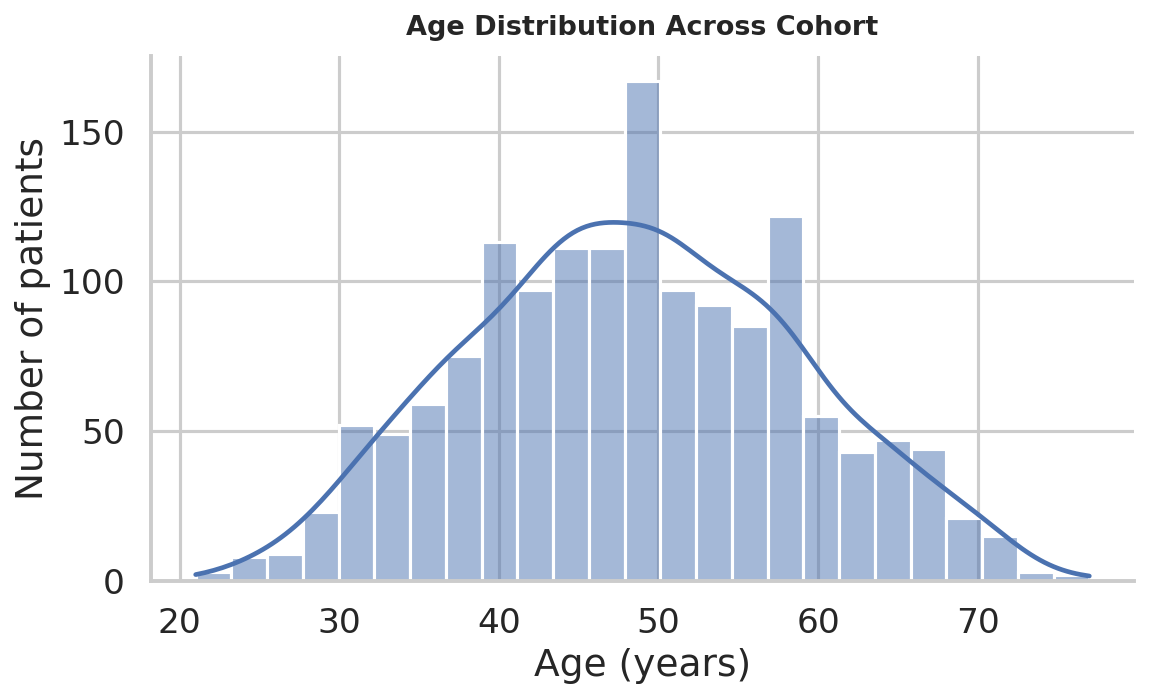

In [24]:
# --- Age distribution ---
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(meta_df, x="age", bins=25, kde=True, color="#4B72B0", ax=ax)
ax.set_title("Age Distribution Across Cohort", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of patients")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/age_hist.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Age vs. PCR

/tmp/ipykernel_1092878/456402925.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pcr_df, x="pcr_cat", y="age", inner="quartile", ax=ax, palette="Set2")


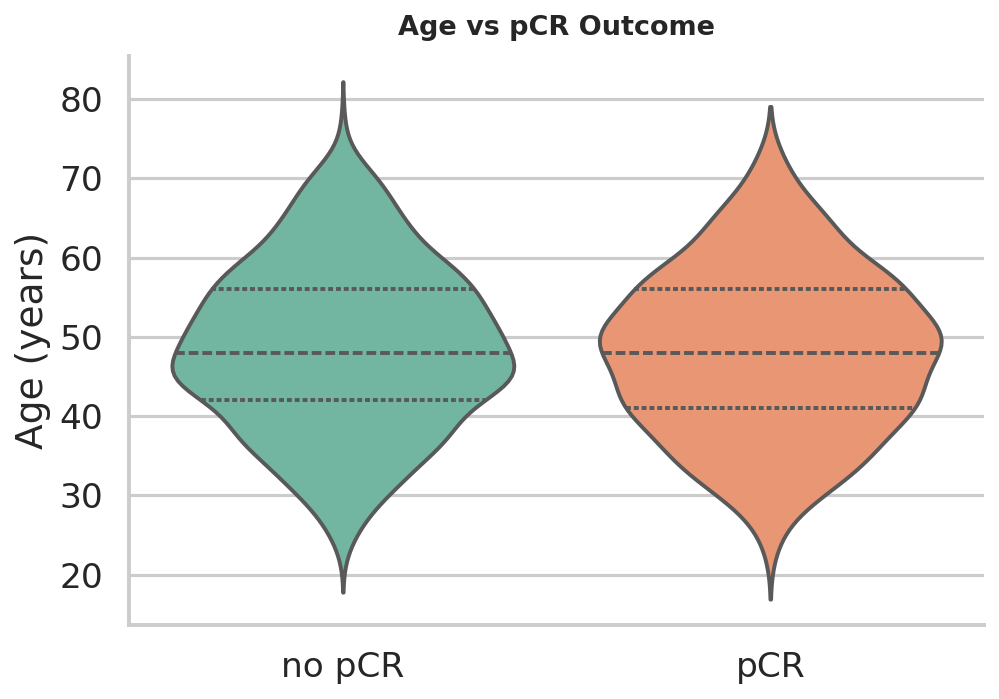

In [26]:
# pCR-labeled subset
pcr_df = meta_df.dropna(subset=["pcr"]).copy()
pcr_df["pcr_cat"] = pcr_df["pcr"].map({0: "no pCR", 1: "pCR"})

fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=pcr_df, x="pcr_cat", y="age", inner="quartile", ax=ax, palette="Set2")
ax.set_title("Age vs pCR Outcome", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Age (years)")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/age_vs_pcr.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Age vs. Subtype

/tmp/ipykernel_1092878/1659704039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_1092878/1659704039.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


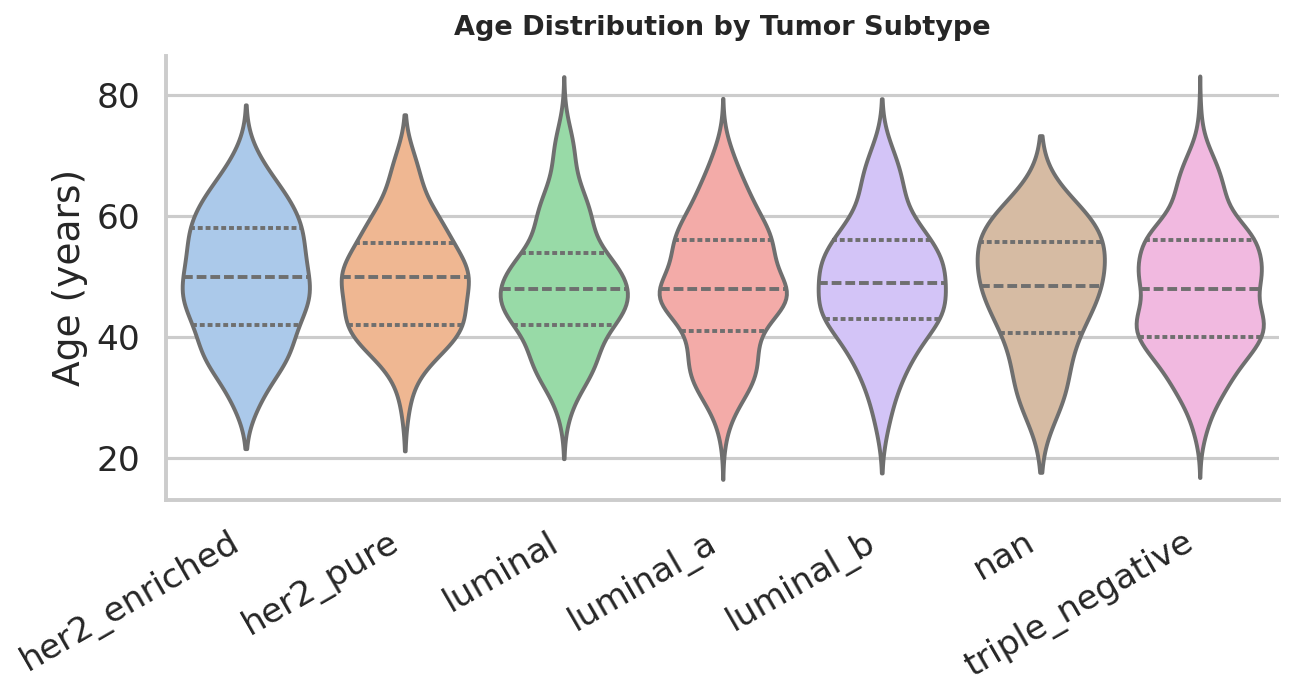

In [28]:
fig, ax = plt.subplots(figsize=(9,5))
sns.violinplot(
    data=pcr_df,
    x="subtype",
    y="age",
    inner="quartile",
    ax=ax,
    palette="pastel",
    order=sorted(pcr_df["subtype"].dropna().unique())
)
ax.set_title("Age Distribution by Tumor Subtype", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Age (years)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/age_vs_subtype.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Menopausal Distribution

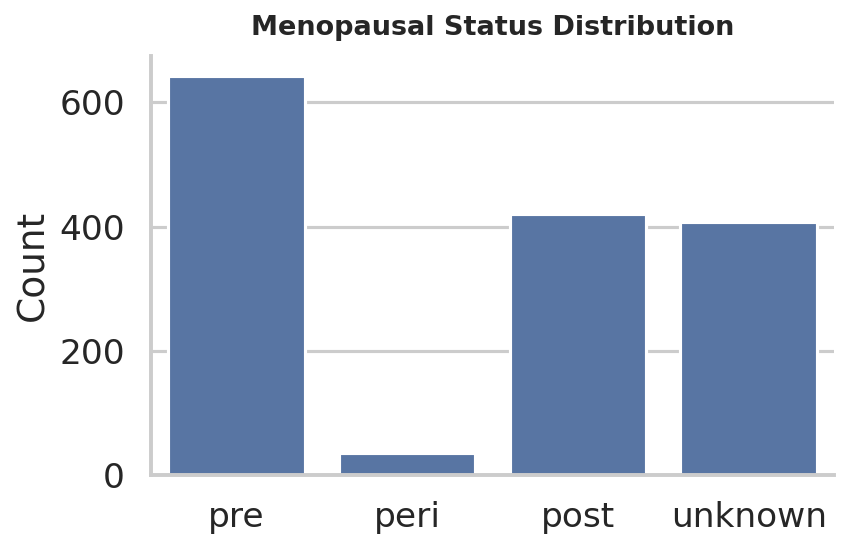

In [30]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=meta_df, x="menopausal", color="#4B72B0", order=["pre","peri","post","unknown"], ax=ax)
ax.set_title("Menopausal Status Distribution", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Count")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/menopausal_status.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Menopausal vs. PCR

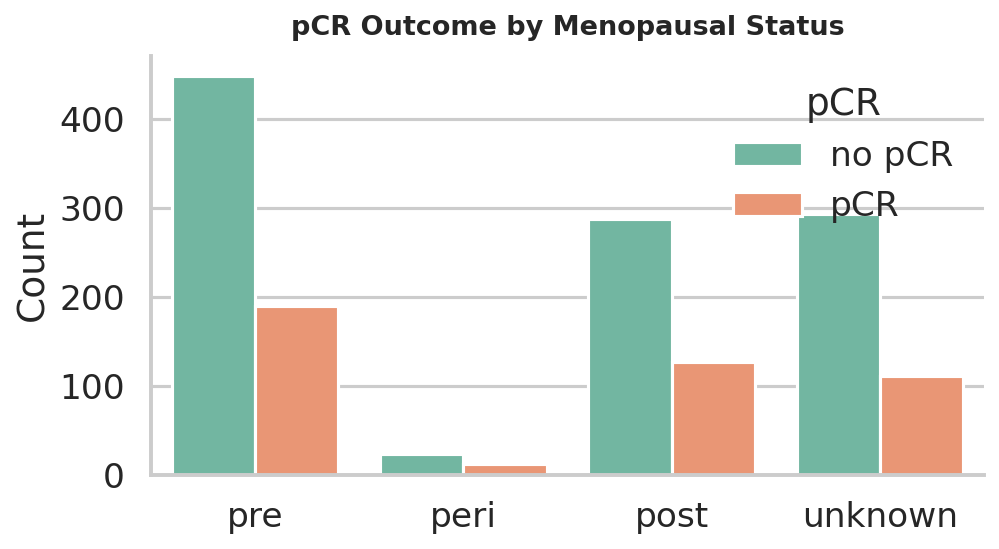

In [32]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(data=pcr_df, x="menopausal", hue="pcr_cat", ax=ax, palette="Set2", order=["pre","peri","post","unknown"])
ax.set_title("pCR Outcome by Menopausal Status", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="pCR", loc="upper right", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/pcr_by_menopausal.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

### Breast Density / Missingness Plot

In [33]:
bd_counts = meta_df["breast_density"].value_counts(dropna=False)
print(bd_counts)
print(f"\nNon-empty values: {(meta_df['breast_density'] != 'unknown').sum()} / {len(meta_df)}")

breast_density
unknown    1446
c            31
b            14
d            12
a             3
Name: count, dtype: int64

Non-empty values: 60 / 1506


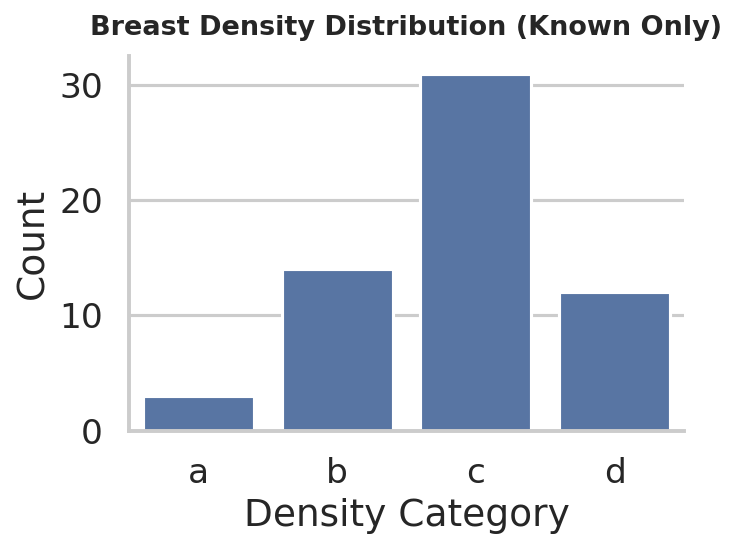

In [37]:
# Plot for the non-unknowns
bd_valid = meta_df.loc[meta_df["breast_density"].isin(["a", "b", "c", "d"])]

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(
    data=bd_valid,
    x="breast_density",
    order=["a", "b", "c", "d"],
    color="#4B72B0",
    ax=ax
)
ax.set_title("Breast Density Distribution (Known Only)", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("Density Category")
ax.set_ylabel("Count")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/breast_density_known.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

#### Missingness

,feature,percent_missing
0,breast_density,96.0
1,menopausal,27.1
2,subtype,1.7
3,pcr,1.0
4,age,0.2
5,site,0.0
6,patient_id,0.0
7,dataset,0.0
8,laterality,0.0
9,bbox_volume,0.0


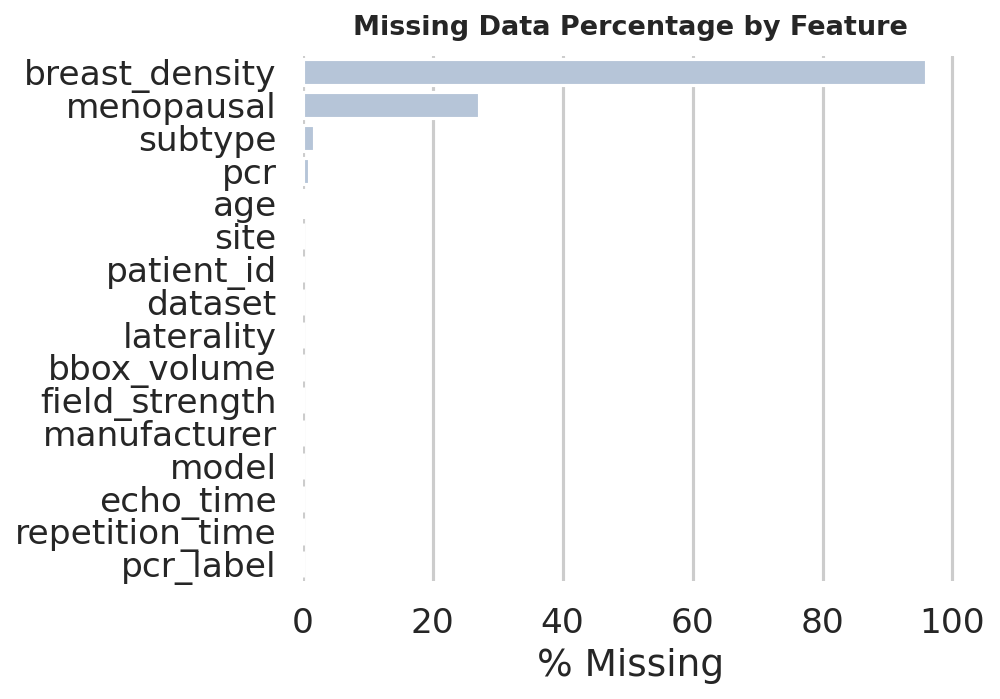

In [41]:
# % missing per column 
meta_df_missing = meta_df.copy()

obj_cols = meta_df_missing.select_dtypes(include="object").columns
meta_df_missing[obj_cols] = meta_df_missing[obj_cols].apply(
    lambda s: s.replace({"unknown": np.nan, "na": np.nan, "nan": np.nan, "": np.nan})
)

# % missing per column
missing_summary = (
    meta_df_missing.isna()
    .mean().mul(100).round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "percent_missing"})
)

display(missing_summary)
savetables(missing_summary, f"{OUT_DIR}/tables/missing_summary.csv")

# plot (horizontal bar)
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=missing_summary, y="feature", x="percent_missing", color="#B0C4DE", ax=ax)
ax.set_title("Missing Data Percentage by Feature", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("% Missing"); ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figs/missing_percent_bar.png", bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

savetables(missing_summary, f"{OUT_DIR}/tables/missing_summary.csv")
